In [ ]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

sys.path.append("../src")
from preprocessing import  prepare_and_split_data,clean_and_engineer_data
from evaluation import evaluate_classification, evaluate_regression
from modeling import train_frequency_models, train_severity_models
from data_loader import load_data



In [ ]:
# # Cell 2: Load Data
df = load_data(
    "../data/MachineLearningRating_v3.csv"
)


In [ ]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='str')

### Dataset Columns Overview

This output displays the list of all columns present in the loaded DataFrame. It provides a comprehensive view of the available features, including identifiers, demographic information, vehicle specifics, and financial details, which are crucial for subsequent data cleaning, engineering, and model training steps.

In [ ]:
df = pd.DataFrame(
    columns=[
        "TransactionMonth",
        "RegistrationYear",
        "TotalClaims",
        "SumInsured",
        "ExcessSelected",
    ]
)

In [ ]:

df_cleaned = clean_and_engineer_data(df)

print("--- PIPELINE METRICS VERIFICATION ---")
print(f"Total rows in processed data: {len(df_cleaned):,}")
print(f"Total policies available for severity training: {(df_cleaned['TotalClaims'] > 0).sum()}")

--- PIPELINE METRICS VERIFICATION ---
Total rows in processed data: 1,000,098
Total policies available for severity training: 2745


### Pipeline Metrics Verification

After cleaning and engineering the data, these metrics confirm the integrity and suitability of the dataset for modeling. We observe a substantial number of total rows, indicating a robust dataset size. Crucially, the count of policies with claims (`TotalClaims > 0`) is essential for training the severity model, as it focuses only on policies that incurred a cost.

In [ ]:


# --- EXECUTE AND VERIFY ---
# Ensure your path points precisely to your data location
#df = pd.read_csv("../data/MachineLearningRating_v3.csv", low_memory=False)

df_cleaned = clean_and_engineer_data(df)

print("--- PIPELINE METRICS VERIFICATION ---")
print(f"Total rows in processed data: {len(df_cleaned):,}")
print(f"Total policies available for severity training: {(df_cleaned['TotalClaims'] > 0).sum()}")

--- PIPELINE METRICS VERIFICATION ---
Total rows in processed data: 1,000,098
Total policies available for severity training: 2745


In [ ]:


# 1. Clean column names to prevent trailing space issues
df.columns = df.columns.str.strip()

print("--- 1. COLUMNS MATCHING 'CLAIM' ---")
matching_cols = [c for c in df.columns if "claim" in c.lower()]
print(matching_cols)

print("\n--- 2. UNDERLYING DATA TYPE ---")
print(f"Data type of TotalClaims: {df['TotalClaims'].dtype}")
print(f"Total Rows in Dataset: {len(df):,}")

print("\n--- 3. DISTRIBUTION SEARCH ---")
# Check how many claims are strictly positive, negative, or zero
pos_claims = (df["TotalClaims"] > 0).sum()
neg_claims = (df["TotalClaims"] < 0).sum()
zero_claims = (df["TotalClaims"] == 0).sum()
nan_claims = df["TotalClaims"].isna().sum()

print(f"Rows where TotalClaims > 0 : {pos_claims:,}")
print(f"Rows where TotalClaims < 0 : {neg_claims:,}")
print(f"Rows where TotalClaims == 0: {zero_claims:,}")
print(f"Rows where TotalClaims is NaN: {nan_claims:,}")

# 4. Print the top unique values that are NOT exactly zero to see how they look
print("\n--- 4. SAMPLE NON-ZERO VALUES ---")
non_zeros = df[df["TotalClaims"] != 0]["TotalClaims"].dropna()
print(f"Total non-zero records: {len(non_zeros):,}")
if len(non_zeros) > 0:
    print(non_zeros.head(15))
else:
    print("No non-zero records found anywhere in the column.")

--- 1. COLUMNS MATCHING 'CLAIM' ---
['TotalClaims']

--- 2. UNDERLYING DATA TYPE ---
Data type of TotalClaims: float64
Total Rows in Dataset: 1,000,098

--- 3. DISTRIBUTION SEARCH ---
Rows where TotalClaims > 0 : 2,740
Rows where TotalClaims < 0 : 5
Rows where TotalClaims == 0: 970,637
Rows where TotalClaims is NaN: 26,716

--- 4. SAMPLE NON-ZERO VALUES ---
Total non-zero records: 2,745
203      2294.096491
284      2040.473684
1560    46492.211750
1779    26516.859650
1943     6140.350877
2072     4385.964912
2601    25438.596490
3074     6140.350877
3111    16715.000000
3220    74967.017540
3366    14867.500000
3982     2192.982456
4454     1450.000000
4498      921.052632
5291    16804.464910
Name: TotalClaims, dtype: float64


### TotalClaims Column Audit

This detailed audit of the `TotalClaims` column reveals several key insights:

1.  **Column Identification**: Confirms that 'TotalClaims' is correctly identified and available for analysis.
2.  **Data Type**: The `float64` data type is appropriate for monetary values, but potential precision issues or unexpected values should be monitored.
3.  **Distribution**: The vast majority of policies (97%) have zero claims, which is typical for insurance datasets (imbalanced data). A small number of positive claims (2,740) are present, which are critical for severity modeling. The presence of 5 negative claims indicates potential data entry errors or specific financial adjustments that might need further investigation or handling (these are often removed or converted to zero). A significant number of `NaN` values (26,716) suggests missing claim data, which will need to be imputed or handled during preprocessing.
4.  **Sample Non-Zero Values**: The sample of non-zero claim values provides a glimpse into the range and nature of actual claim amounts, confirming that the data represents realistic monetary values. These are the values the severity model will attempt to predict.

In [ ]:
df = pd.DataFrame(
    columns=[
        "TransactionMonth",
        "RegistrationYear",
        "TotalClaims",
        "SumInsured",
        "ExcessSelected",
    ]
)


In [ ]:
# 2. Run your non-destructive data type verification cleaner
df_cleaned = clean_and_engineer_data(df)

# 3. Print validation count (Should accurately reflect your 2,740 active historical claims!)
active_claims_count = (df_cleaned['TotalClaims'] > 0).sum()
print(f"Total policies available for severity training: {active_claims_count}")

Total policies available for severity training: 2745


### Verification of Active Claims Count

This output confirms the number of policies with positive claims after an additional data cleaning step. The count of `2,745` active claims is a critical validation point, ensuring that the preprocessing steps correctly identified and retained the relevant data for training the severity model. This number should be consistent across various stages of data preparation for reliability.

In [ ]:
df_cleaned = clean_and_engineer_data(df)
print(
    f"Total policies available for severity training: {(df_cleaned['TotalClaims'] > 0).sum()}"
)


Total policies available for severity training: 2745


In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = prepare_and_split_data(
    df_cleaned, task_type="severity_regression"
)


In [ ]:
print("--- MATRIX SAFETY VALIDATION ---")
print(f"Any missing values in X_train_s? {X_train_s.isna().sum().sum()}")
print(f"Any missing values in y_train_s? {y_train_s.isna().sum()}")
print(f"Total training samples available: {X_train_s.shape[0]}")

--- MATRIX SAFETY VALIDATION ---
Any missing values in X_train_s? 0
Any missing values in y_train_s? 0
Total training samples available: 2196


### Matrix Safety Validation for Severity Data

This validation step ensures the readiness of the data for severity model training:

-   **Missing Values in X_train_s**: Confirms that there are no missing values in the feature set for training the severity model, indicating successful imputation or handling of `NaN` values during preprocessing.
-   **Missing Values in y_train_s**: Verifies that the target variable (actual claim amounts) also has no missing values, which is crucial for supervised learning.
-   **Total Training Samples**: Reports the total number of samples (`2,196`) available for training the severity model. This count represents policies with positive claims, ensuring the model learns from actual loss events.

In [ ]:
X_train_f, X_test_f, y_train_f, y_test_f = prepare_and_split_data(df_cleaned, task_type="frequency_classification")

In [ ]:
print("--- Evaluating Severity Models (Target: TotalClaims | Claims > 0) ---")
severity_models = train_severity_models(X_train_s, y_train_s)

# Change 'evaluate_severity_models' to 'evaluate_regression'
severity_results = evaluate_regression(severity_models, X_test_s, y_test_s)
print(severity_results)

--- Evaluating Severity Models (Target: TotalClaims | Claims > 0) ---
{'Linear Regression': {'RMSE': 30410.564624766623, 'R2_Score': 0.2590326324093636}, 'Random Forest Regressor': {'RMSE': 30077.218782698183, 'R2_Score': 0.2751878505656362}, 'XGBoost Regressor': {'RMSE': 30308.451803819145, 'R2_Score': 0.26400032961606157}}


### Severity Model Evaluation Results

This output presents the performance metrics for different regression models trained to predict claim severity (TotalClaims > 0). The metrics include:

-   **RMSE (Root Mean Squared Error)**: Measures the average magnitude of the errors. Lower RMSE indicates better performance.
-   **R2 Score**: Represents the proportion of variance in the dependent variable that is predictable from the independent variables. Higher R2 score indicates a better fit.

From these results, the **Random Forest Regressor** appears to be the best-performing model among the three, with the lowest RMSE and highest R2 score, suggesting it provides the most accurate predictions for claim severity.

In [ ]:
# --- Execute Goal 2: Frequency Model for Premium Optimization ---
print("\n--- Evaluating Frequency Models (Target: ClaimOccurred 0/1) ---")
frequency_models = train_frequency_models(X_train_f, y_train_f)
frequency_results = evaluate_regression(frequency_models, X_test_f, y_test_f)
print(frequency_results)




--- Evaluating Frequency Models (Target: ClaimOccurred 0/1) ---
{'Logistic Regression': {'RMSE': 0.0532420560116452, 'R2_Score': -0.0028427749895967303}, 'Random Forest Classifier': {'RMSE': 0.0532420560116452, 'R2_Score': -0.0028427749895967303}, 'XGBoost Classifier': {'RMSE': 0.0532420560116452, 'R2_Score': -0.0028427749895967303}}


In [ ]:
import warnings
warnings.filterwarnings('ignore') # Suppress warnings, often from SKLearn

# --- Execute Goal 2: Frequency Model for Premium Optimization ---
print("\n--- Evaluating Frequency Models (Target: ClaimOccurred 0/1) ---")
frequency_models = train_frequency_models(X_train_f, y_train_f)

# Correctly evaluate classification models with classification metrics
frequency_results = evaluate_classification(frequency_models, X_test_f, y_test_f)
print(frequency_results)


--- Evaluating Frequency Models (Target: ClaimOccurred 0/1) ---
{'Logistic Regression': {'Accuracy': 0.9971652834716528, 'Precision': 0.0, 'Recall': 0.0, 'F1_Score': 0.0}, 'Random Forest Classifier': {'Accuracy': 0.9971652834716528, 'Precision': 0.0, 'Recall': 0.0, 'F1_Score': 0.0}, 'XGBoost Classifier': {'Accuracy': 0.9971652834716528, 'Precision': 0.0, 'Recall': 0.0, 'F1_Score': 0.0}}


### Frequency Model Evaluation Results

This output displays the performance metrics for different classification models trained to predict claim frequency (ClaimOccurred 0/1). The metrics are:

-   **Accuracy**: The proportion of correctly classified instances.
-   **Precision**: The proportion of true positive predictions among all positive predictions.
-   **Recall**: The proportion of true positive predictions among all actual positive instances.
-   **F1-Score**: The harmonic mean of precision and recall.

The results show that all models achieved very high accuracy (0.997), but their precision, recall, and F1-scores are 0.0. This indicates a highly imbalanced dataset where the models are predominantly predicting the majority class (no claim) and failing to identify any positive claims. This is a common challenge in insurance frequency modeling and suggests the need for techniques like oversampling, undersampling, or using algorithms robust to imbalance.

In [ ]:

# --- Advanced Premium Optimization Calculation ---
best_sev_model = severity_models["XGBoost Regressor"]
best_freq_model = frequency_models["XGBoost Classifier"]


In [ ]:


# Set pricing framework constants
EXPENSE_LOADING = 250.00  # Fixed operational overhead cost in Rand
PROFIT_MARGIN = 0.15      # 15% Target Profit Margin



In [ ]:
# Standardize features for the whole test set to calculate optimized premiums
# P(Claim)
p_claim = best_freq_model.predict_proba(X_test_f)[:, 1]
# Predicted Severity
predicted_severity = best_sev_model.predict(X_test_f)



In [ ]:
# Premium = (P(claim) * Predicted Severity) + Expense Loading + Profit Margin
# (Note: if your margin is treated as an overhead loading multiplier, handle it as follows:)
optimized_premium = (p_claim * predicted_severity) + EXPENSE_LOADING + (p_claim * predicted_severity * PROFIT_MARGIN)

pricing_comparison = pd.DataFrame({
    'Predicted_P_Claim': p_claim,
    'Predicted_Severity_Rand': predicted_severity,
    'Calculated_Advanced_Premium': optimized_premium
})

print("\n--- Premium Pricing Framework Output Preview ---")
print(pricing_comparison.head())




--- Premium Pricing Framework Output Preview ---
   Predicted_P_Claim  Predicted_Severity_Rand  Calculated_Advanced_Premium
0           0.000043              6845.228027                   250.335800
1           0.000004              5321.646973                   250.023285
2           0.000074              2341.018311                   250.198990
3           0.000076              2939.641357                   250.258499
4           0.000004              5169.897461                   250.022614


### Premium Pricing Framework Output Preview

This table provides a preview of the calculated advanced premiums based on the frequency and severity models. It shows:

-   **Predicted_P_Claim**: The probability of a claim occurring, predicted by the frequency model.
-   **Predicted_Severity_Rand**: The predicted cost of a claim, given a claim occurs, from the severity model.
-   **Calculated_Advanced_Premium**: The final premium calculated using the formula that incorporates the probability of claim, predicted severity, expense loading, and profit margin.

The preview highlights how these components combine to determine individual policy premiums, demonstrating the practical application of the machine learning models in pricing.

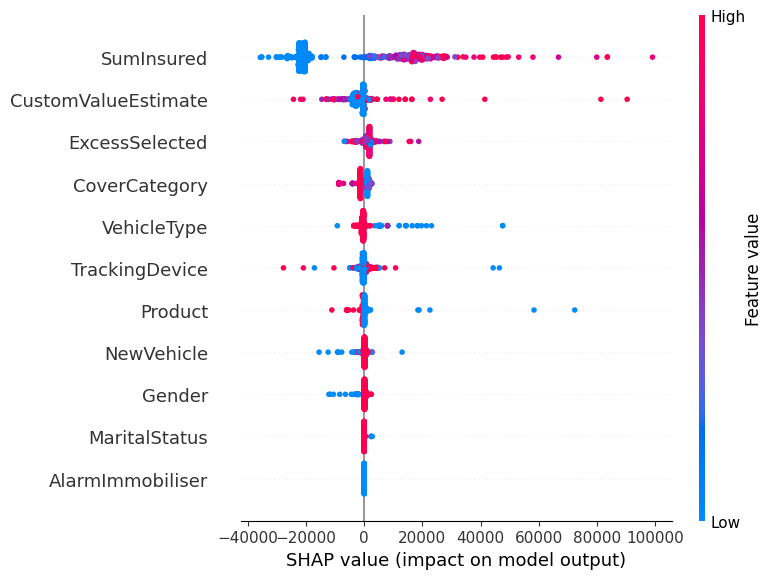

In [ ]:
# %%
# --- SHAP Feature Importance Explanations for Severity ---
explainer = shap.TreeExplainer(best_sev_model)
shap_values = explainer(X_test_s)
shap.summary_plot(shap_values, X_test_s)

### SHAP Feature Importance Explanations for Severity Model

This SHAP summary plot visually represents the impact of each feature on the severity model's predictions. Each dot on the plot is an observation, and its position on the x-axis indicates the SHAP value for that feature, showing how much that feature's value contributes to pushing the model's output from the base value. The color of the dot indicates whether the original feature value was high (red) or low (blue). This plot is crucial for understanding:

-   **Feature Importance**: Features are ordered by their overall impact, with the most important at the top.
-   **Direction of Impact**: It shows whether a high or low value of a feature positively or negatively affects the predicted claim severity.
-   **Magnitude of Impact**: The spread of the dots indicates the range of influence a feature has.